# Ridge Regression Based Model for Predicting Crop Yield
**Unit II Project — B.Tech CSE (AI/ML), SRM IST**

**Dataset:** [Crop Yield Prediction using Soil and Weather](https://www.kaggle.com/datasets/gurudathg/crop-yield-prediction-using-soil-and-weather)

**PBL brief:** Unit I covered EDA; Unit II requires implementation and comparative
evaluation of regression (and classification) algorithms. This notebook implements
**Ridge Regression** as the primary model, benchmarked against Linear, Lasso,
ElasticNet and Random Forest regressors, with a short EDA recap, full preprocessing
pipeline, hyperparameter tuning, and evaluation.



## 1. Problem Understanding

**Task:** Predict crop yield (a continuous variable) from soil nutrient levels
(N, P, K, pH) and weather variables (temperature, humidity, rainfall), using
**Ridge Regression** — linear regression with an L2 penalty that shrinks
coefficients to reduce variance and handle multicollinearity between correlated
predictors (e.g. temperature and humidity, or N/P/K levels).

**Why Ridge here?**
- Soil and weather features are often correlated (multicollinearity) → OLS
  coefficients become unstable/inflated → Ridge's L2 penalty stabilizes them.
- We still want an interpretable linear model (unlike a black-box like Random Forest),
  useful for agricultural decision-making.

**Why compare against other models?**
The PBL brief asks for *comparative evaluation*. We use Linear Regression as the
un-regularized baseline, Lasso/ElasticNet as alternative regularization strategies,
and Random Forest as a non-linear benchmark to show where linear assumptions break down.


In [3]:
!pip install -q "numpy==2.2.6" "pandas==2.2.3" "scikit-learn==1.6.1" --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.5/347.5 kB 20.0 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
import numpy, pandas, sklearn
print(numpy.__version__, pandas.__version__, sklearn.__version__)

2.2.6 2.2.3 1.6.1


## 2. Data Collection

Two ways to get the dataset into Colab — use whichever is easier for you.

**Option A — Kaggle API (recommended, fully reproducible):**
1. Go to kaggle.com → Account → "Create New API Token" → downloads `kaggle.json`.
2. Run the cell below, upload `kaggle.json` when prompted.

**Option B — Manual upload:**
Download the CSV from the Kaggle dataset page yourself, then use the Colab file
upload cell (second cell below) to upload it directly.


In [3]:
import pandas as pd

df = pd.read_csv('/content/Crop Yiled with Soil and Weather.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)
print("\nHead:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe(include='all'))

Shape: (2596, 6)

Columns: ['Fertilizer', 'temp', 'N', 'P', 'K', 'yeild']

Dtypes:
 Fertilizer    float64
temp          float64
N             float64
P             float64
K             float64
yeild         float64
dtype: object

Head:
    Fertilizer  temp     N     P     K  yeild
0        80.0  28.0  80.0  24.0  20.0   12.0
1        77.0  27.0  78.0  23.0  20.0   12.0
2        80.0  26.0  80.0  24.0  20.0   12.0
3        80.0  28.0  80.0  24.0  20.0   12.0
4        78.0  27.0  78.0  23.0  19.0   12.0

Missing values:
 Fertilizer    0
temp          0
N             0
P             0
K             0
yeild         0
dtype: int64

Describe:
         Fertilizer         temp            N            P            K  \
count  2596.000000  2596.000000  2596.000000  2596.000000  2596.000000   
mean     66.487433    33.848237    69.522900    20.708194    17.806268   
std       9.747669     5.371279     6.802806     1.973419     1.940037   
min      49.751436    23.771310    58.839466    17.723223

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_style("whitegrid")

df = pd.read_csv('/content/Crop Yiled with Soil and Weather.csv')
df = df.rename(columns={'yeild': 'yield'})  # fix typo for readability
df.head()

,Fertilizer,temp,N,P,K,yield
0,80.0,28.0,80.0,24.0,20.0,12.0
1,77.0,27.0,78.0,23.0,20.0,12.0
2,80.0,26.0,80.0,24.0,20.0,12.0
3,80.0,28.0,80.0,24.0,20.0,12.0
4,78.0,27.0,78.0,23.0,19.0,12.0


## 3. Exploratory Data Analysis (recap from Unit I)

Even though full EDA was done in Unit I, we recap the essentials here so the
preprocessing and modelling choices below are justified in this report.


        Fertilizer         temp            N            P            K  \
count  2596.000000  2596.000000  2596.000000  2596.000000  2596.000000   
mean     66.487433    33.848237    69.522900    20.708194    17.806268   
std       9.747669     5.371279     6.802806     1.973419     1.940037   
min      49.751436    23.771310    58.839466    17.723223    14.704883   
25%      59.865423    28.000000    64.834635    18.988224    15.975932   
50%      65.011969    36.965121    69.894076    20.889579    18.061975   
75%      76.943112    38.928914    76.845919    22.125618    19.133858   
max      80.223893    40.272480    80.218705    25.162178    22.064666   

             yield  
count  2596.000000  
mean      8.533832  
std       1.938789  
min       5.150745  
25%       6.929404  
50%       8.501720  
75%      10.045179  
max      12.337651  

Missing values:
 Fertilizer    0
temp          0
N             0
P             0
K             0
yield         0
dtype: int64


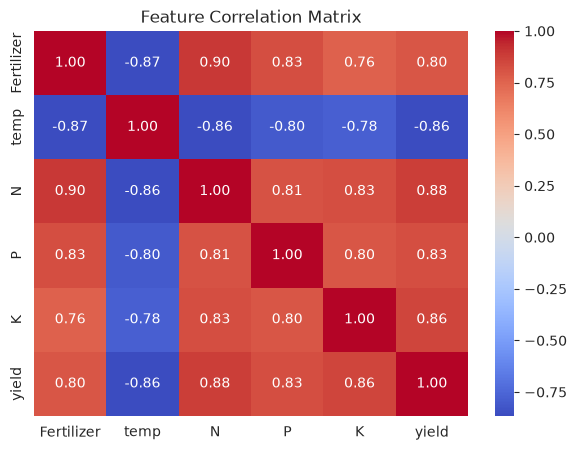

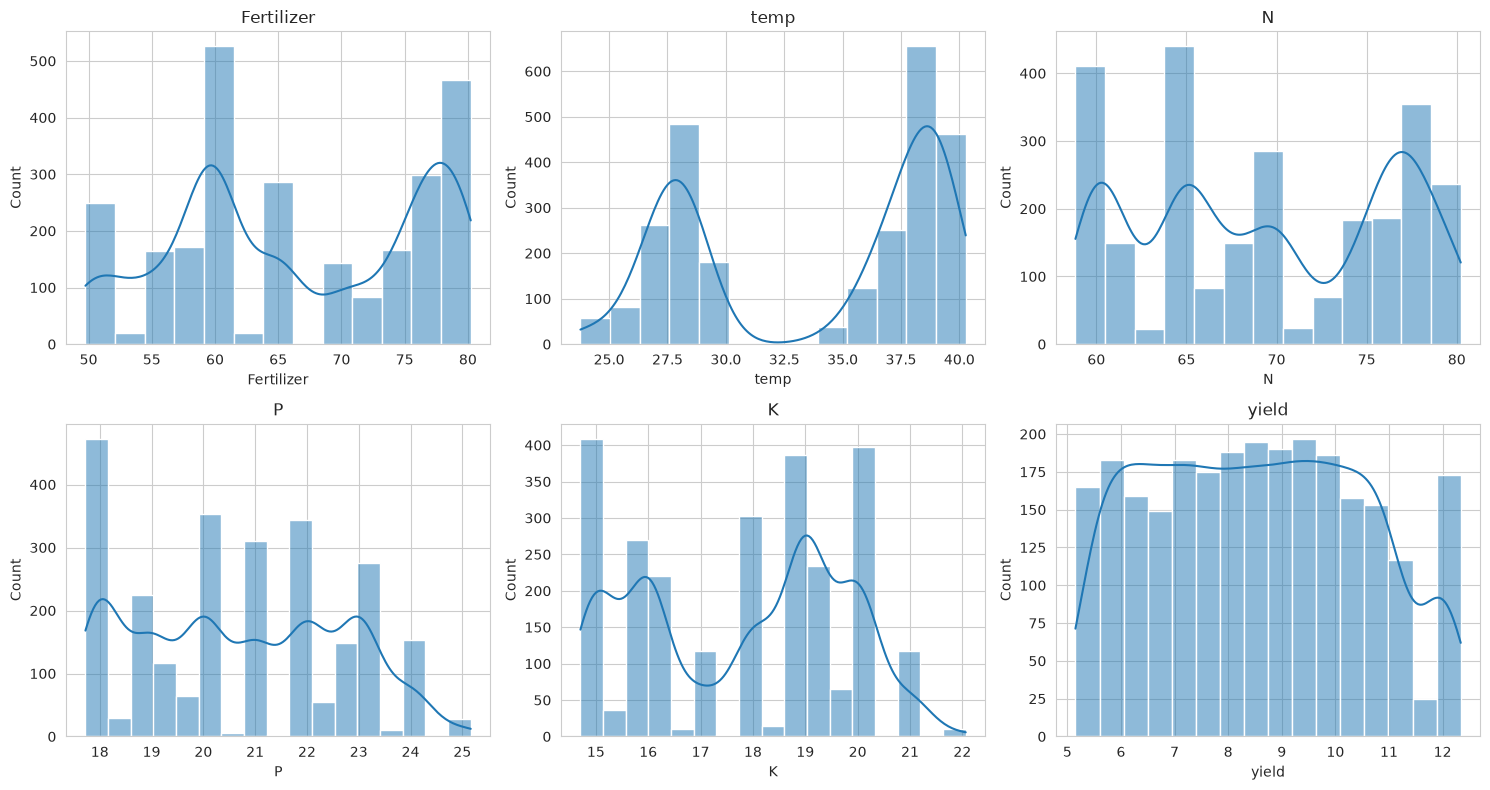

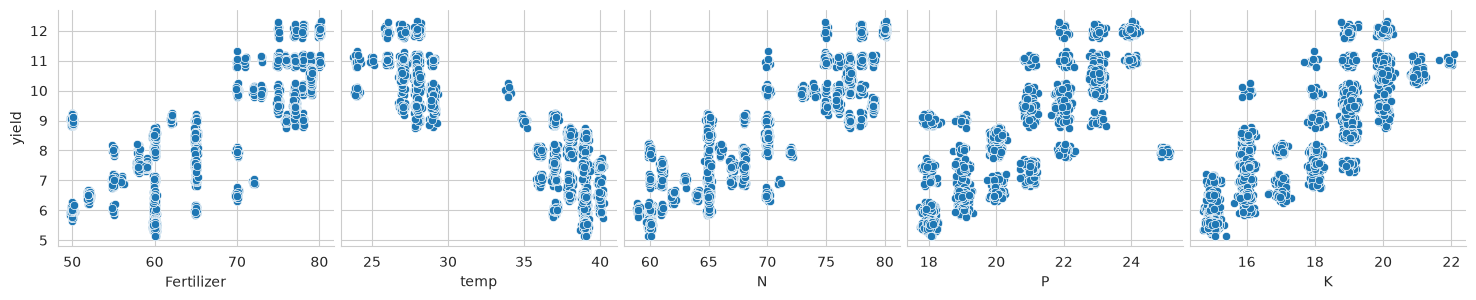

In [5]:
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())

# Correlation heatmap — this is the key plot for justifying ridge regression
plt.figure(figsize=(7,5))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

# Distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, df.columns):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Pairplot vs target
sns.pairplot(df, y_vars=['yield'], x_vars=['Fertilizer', 'temp', 'N', 'P', 'K'], height=3)
plt.show()

## 4. Preprocessing

Steps, and why each matters for Ridge specifically:
1. **Drop / impute missing values** — Ridge cannot handle NaNs.
2. **Encode categorical columns** (e.g. crop/soil type) with one-hot encoding.
3. **Train/test split** — hold out data to evaluate generalization.
4. **Feature scaling (StandardScaler)** — critical for Ridge: the L2 penalty
   `alpha * sum(coef^2)` penalizes large coefficients, so **unscaled features
   with larger numeric ranges get penalized unfairly** unless all features are
   put on the same scale first.


In [6]:
X = df.drop(columns=['yield'])
y = df['yield']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)

Train: (2076, 5) Test: (520, 5)


## 5. Model Implementation — Ridge Regression (primary model)

We first tune the regularization strength **alpha** using cross-validated
`RidgeCV`, then confirm with a manual `GridSearchCV` for transparency (useful
to walk through in viva).


Best alpha: 1.5264179671752334


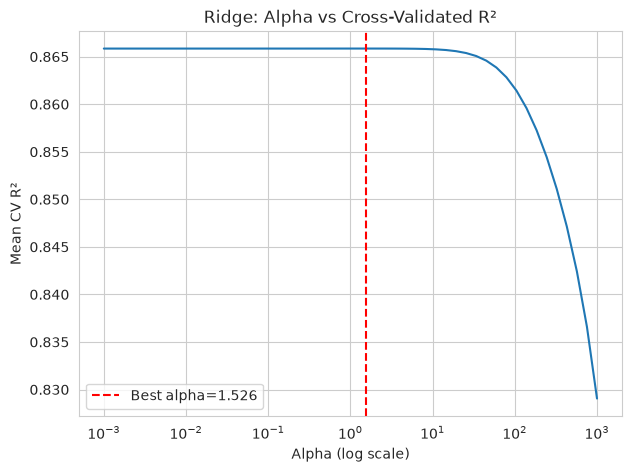

In [7]:
alphas = np.logspace(-3, 3, 50)
ridge_cv = GridSearchCV(
    Ridge(),
    param_grid={'alpha': alphas},
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2'
)
ridge_cv.fit(X_train_scaled, y_train)

best_alpha = ridge_cv.best_params_['alpha']
print("Best alpha:", best_alpha)

ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(X_train_scaled, y_train)

# Alpha vs R2 plot — good for viva
plt.figure(figsize=(7,5))
plt.plot(alphas, ridge_cv.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean CV R²')
plt.title('Ridge: Alpha vs Cross-Validated R²')
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best alpha={best_alpha:.3f}')
plt.legend()
plt.show()

## 6. Comparative Evaluation — other regression algorithms

To satisfy the "comparative evaluation" requirement, we benchmark Ridge against:
- **Linear Regression** — unregularized baseline (shows why regularization helps)
- **Lasso** — L1 regularization (can zero out features entirely, useful for feature selection)
- **ElasticNet** — combined L1 + L2
- **Random Forest Regressor** — non-linear benchmark, to check whether linear
  models are actually capturing the yield relationship well


In [8]:
models = {
    'Linear Regression (OLS)': LinearRegression(),
    'Ridge Regression': Ridge(alpha=best_alpha),
    'Lasso Regression': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'R2': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(results_df.to_string(index=False))

                  Model       R2     RMSE      MAE
       Lasso Regression 0.863699 0.715722 0.582286
             ElasticNet 0.863623 0.715921 0.582076
       Ridge Regression 0.862736 0.718245 0.579318
Linear Regression (OLS) 0.862648 0.718474 0.579096


## 7. Results, Evaluation & Interpretation

### 7.1 Ridge coefficients — which features drive predicted yield?


      Feature       OLS     Ridge     Lasso
0  Fertilizer -0.537947 -0.531745 -0.402485
1        temp -0.690750 -0.688737 -0.648248
2           N  0.832850  0.828513  0.758932
3           P  0.422866  0.421919  0.387945
4           K  0.503753  0.504554  0.512449


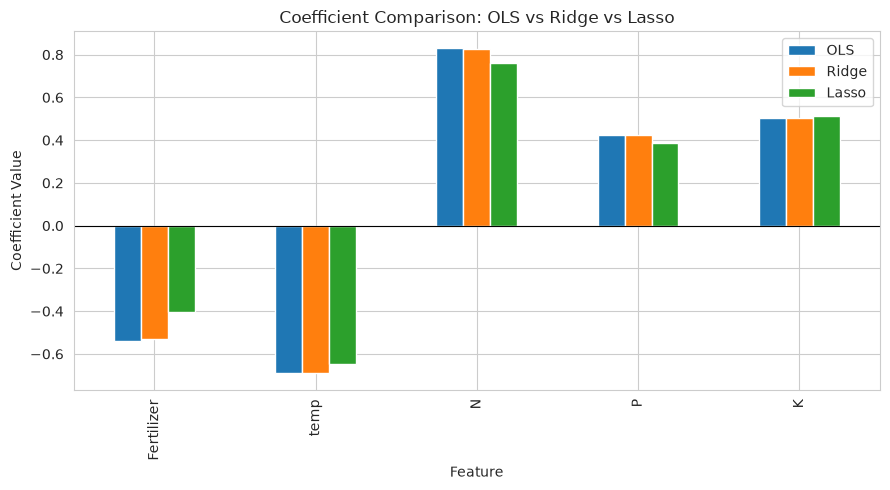

In [9]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'OLS': models['Linear Regression (OLS)'].coef_,
    'Ridge': models['Ridge Regression'].coef_,
    'Lasso': models['Lasso Regression'].coef_
})
print(coef_df)

coef_df.set_index('Feature').plot(kind='bar', figsize=(9,5))
plt.title('Coefficient Comparison: OLS vs Ridge vs Lasso')
plt.ylabel('Coefficient Value')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

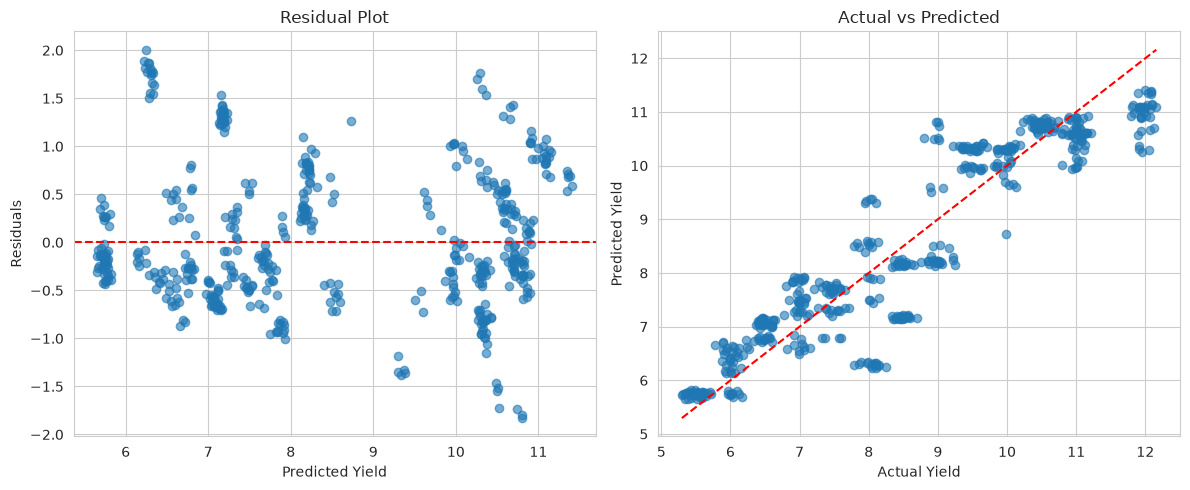

In [10]:
y_pred_ridge = ridge_model.predict(X_test_scaled)
residuals = y_test - y_pred_ridge

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].scatter(y_pred_ridge, residuals, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Yield')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')

axes[1].scatter(y_test, y_pred_ridge, alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual Yield')
axes[1].set_ylabel('Predicted Yield')
axes[1].set_title('Actual vs Predicted')
plt.tight_layout()
plt.show()